# 04. The feynsage toolbox

The tools behind the other notebooks, one by one: Feynman graphs and their Symanzik polynomials, integral
families, integration-by-parts (IBP) reduction (exact and with finite fields), master integrals, differential
equations, sector decomposition, Mellin–Barnes, the Package-X style one-loop layer, FORM, plots, parallel
work and the help built into every function. Each section is short and can be read alone (run the first
cell first).

Normalization reminder: `family` and `graph` use Euclidean propagators l² + m² and the measure dᴰl/π^{D/2}
unless `euclidean=False` is given; the one-loop functions A0, B0, C0, D0 and `loop` use Minkowski space and
the Package-X normalization.

In [1]:
from feynsage import *
from feynsage import gpl
from feynsage.plotting import quick_plot, set_theme, draw_panels, draw_sectors, draw_graph, curves, mb_plane
import time
set_theme()

## 1. Feynman graphs

`graph(edges, legs, kin)` makes a graph from text. Edges are written `"A-B"` between vertices A and B (`:m` gives
the line a mass), `legs` says which momentum enters at which vertex, and `kin` gives the external scalar
products. Lines are numbered x1, x2, ... in the order written.

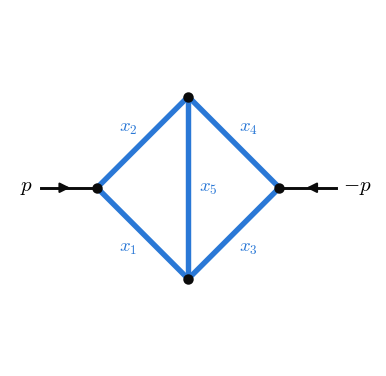

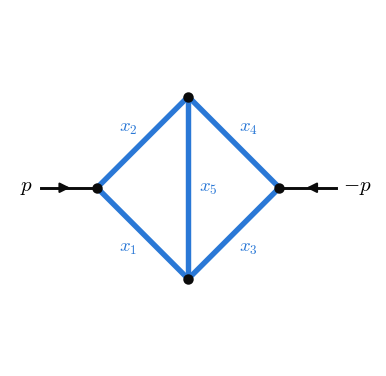

In [2]:
kite = graph("L-B, L-T, B-R, T-R, T-B", {"L": "p", "R": "-p"}, kin={"p^2": "pp"})
kite.plot(figsize=(3, 3))

The first Symanzik polynomial U is the sum over spanning trees of the products of the Feynman parameters of the
lines *not* in the tree; the second, F, comes from the 2-forests. feynsage draws them:

8 spanning trees (each removes L = 2 lines)


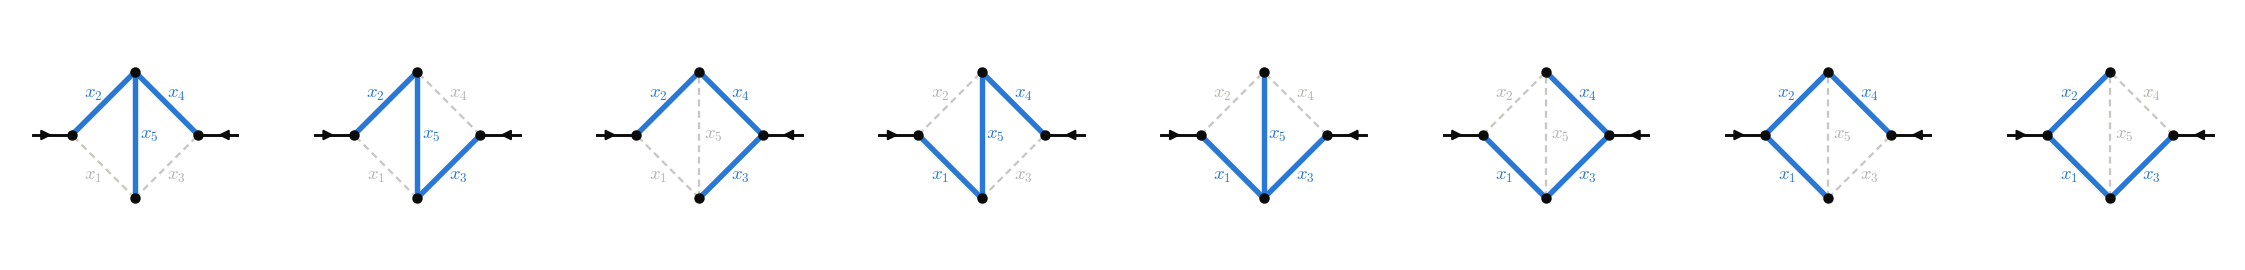

In [3]:
trees = kite.spanning_trees()
print(len(trees), "spanning trees (each removes L = 2 lines)")
draw_panels(kite, trees, momenta=False, ncols=8)

In [4]:
show(kite.U())
show(kite.F())
print("U from the matrix-tree theorem is the same:", kite.U_kirchhoff() == kite.U())

x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5

(-pp)*x1*x2*x3 + (-pp)*x1*x2*x4 + (-pp)*x1*x3*x4 + (-pp)*x2*x3*x4 + (-pp)*x1*x2*x5 + (-pp)*x2*x3*x5 + (-pp)*x1*x4*x5 + (-pp)*x3*x4*x5

U from the matrix-tree theorem is the same: True


A list of ready-made diagrams:

In [5]:
diagram()

tadpole      one massive line from a vertex back to itself
bubble       massless bubble, p^2 = s
bubble_mass  equal-mass bubble
triangle     massless triangle with three off-shell legs
box          massless box, on-shell legs, s and t
sunset       two-loop sunset, three equal masses
kite         two-loop massless kite
phi4_two     two-loop phi^4 diagram of the notes
vertex2      planar two-loop vertex, on-shell massless legs (lines x1..x6 as in the notes)
banana3      three-loop banana, four equal masses
ladder3      three-loop massless ladder propagator
triplebox    three-loop massless planar triple box, on-shell legs, s and t


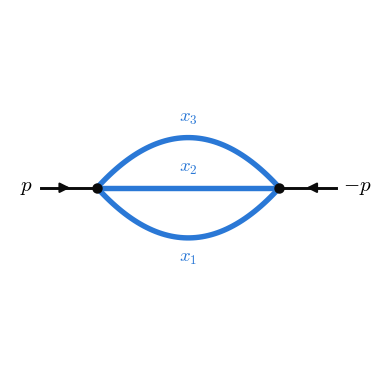

In [6]:
diagram("sunset").plot(figsize=(3, 3))

## 2. Integral families and IBP identities

`family(propagators, kin)` makes a family of integrals J(a1, a2, ...) with the propagators raised to the powers
a_i. A propagator is a momentum `"l + p"` or a pair `("l + p", "m")` for a massive line. The IBP identities
come from ∫ dᴰl ∂/∂l^μ (v^μ × integrand) = 0.

In [7]:
bub = family([("l", "m"), ("l - p", "m")], kin={"p^2": "pp"}, name="J")
bub.info()

Integral family 'J'
  loop momenta: l   external momenta: p   Minkowski metric
  D1 = (l)^2 - m^2
  D2 = (l - 1*p)^2 - m^2
  J(a1,...,at) = Int prod_r d^d l_r prod_i D_i^(-a_i), a_i <= 0 is a numerator.


In [8]:
for eq_ in bub.ibp_eq():                  # with symbolic powers a1, a2
    show(eq_)

-2*a1*m^2*J(a1 + 1, a2) - (2*m^2 - pp)*a2*J(a1, a2 + 1) - a2*J(a1 - 1, a2 + 1) - (2*a1 + a2 - d)*J(a1, a2) == 0

-a1*pp*J(a1 + 1, a2) + a2*pp*J(a1, a2 + 1) + a1*J(a1 + 1, a2 - 1) - a2*J(a1 - 1, a2 + 1) - (a1 - a2)*J(a1, a2) == 0

Which sectors are zero (scaleless) and which permutations of the lines leave the family the same:

In [9]:
kfam = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": 1})
print("symmetries:", symmetries(kfam))
for sector in [(1, 1, 0, 0, 0), (1, 0, 1, 0, 1), (0, 1, 1, 0, 1)]:
    print(sector, "zero" if kfam.is_zero_sector(sector) else "non-zero")

symmetries: [(1, 0, 3, 2, 4), (2, 3, 0, 1, 4)]
(1, 1, 0, 0, 0) zero
(1, 0, 1, 0, 1) zero
(0, 1, 1, 0, 1) non-zero


## 3. IBP reduction to master integrals

`ibp_reduce(family, targets)` reduces integrals to master integrals (Laporta's algorithm). `method="ff"` does it
with finite fields (modular arithmetic and rational reconstruction, as FIRE and Kira do), `"exact"` with exact
rational functions; both give the same answer.

In [10]:
r = ibp_reduce(bub, ["J(2,1)", "J(2,2)", "J(3,1)"])
print("masters:", r.masters)
r

masters: [(0, 1), (1, 1)]


J(2,1) = [(-1) * (d - 3) * (-4*m^2 + pp)^-1] J(1,1) + [(1/2) * m^-2 * (d - 2) * (-4*m^2 + pp)^-1] J(0,1)
J(2,2) = [pp^-1 * (d - 3) * (-4*m^2 + pp)^-2 * (4*m^2 + d*pp - 6*pp)] J(1,1) + [m^-2 * pp^-1 * (d - 2) * (-4*m^2 + pp)^-2 * (-2*d*m^2 + 6*m^2 + pp)] J(0,1)
J(3,1) = [(1/2) * pp^-1 * (d - 3) * (-4*m^2 + pp)^-2 * (-4*m^2 + d*pp - 4*pp)] J(1,1) + [(1/8) * m^-4 * pp^-1 * (d - 2) * (-4*m^2 + pp)^-2 * (8*d*m^4 - 24*m^4 - 8*d*m^2*pp + 32*m^2*pp + d*pp^2 - 4*pp^2)] J(0,1)

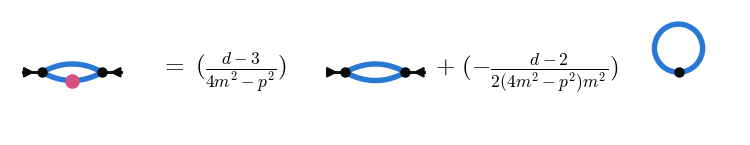

In [11]:
g = graph("A-B:m, A-B:m", {"A": "p", "B": "-p"}, kin={"p^2": "pp"})
r.draw(g, targets=["J(2,1)"], rename={"pp": "p^2"}, size=1.0)

A two-loop example: the massless kite with a high power. The three methods agree and the finite-field one is
fastest:

In [12]:
res = {}
for method in ["ff", "trimmed", "exact"]:
    res[method] = ibp_reduce(kfam, ["F(2,2,1,2,2)"], method=method)
    print("%-8s %6.2f s" % (method, res[method].seconds))
print("all three the same:", res["ff"].table == res["trimmed"].table == res["exact"].table)
res["ff"]

ff         0.33 s
trimmed    0.12 s


exact      5.51 s
all three the same: True


F(2,2,1,2,2) = [(-4) * (d - 8)^-1 * (d - 9) * (d - 6) * (d - 5) * (d - 3)] F(1,1,1,1,0) + [(-729) * (d - 8)^-2 * (d - 10)^-1 * (d - 4)^-1 * (d - 7) * (d - 16/3) * (d - 14/3) * (d - 10/3) * (d - 8/3) * (d^2 - 11*d + 20)] F(0,1,1,0,1)

## 4. How many master integrals?

The number of master integrals of a sector is the number of critical points of G = U + F (Lee and Pomeransky).
For the equal-mass bubble the family has two (the bubble and the tadpole):

In [13]:
eqb = family([["l", "m^2"], ["l - p", "m^2"]], kin={"p^2": "pp"}, euclidean=True)
master_count(eqb, [(1, 1), (1, 0)], {"pp": 11/5, "m": 1})

{(1, 1): 1, (1, 0): 1}

## 5. Differential equations

Differentiating a master integral with respect to an invariant and reducing the result gives a closed system
dJ/dx = A J. For the equal-mass bubble with the masters J(1,1) and J(0,1):

In [14]:
Jm = family([["l", "m2"], ["l - p", "m2"]], kin={"p^2": "pp"}, euclidean=True, name="Jm")
A = differential_equation(Jm, ["J(1,1)", "J(0,1)"], "pp")
A.apply_map(lambda z: z.factor())

[-1/2*(4*m2^2 - d*pp + 4*pp)/((4*m2^2 + pp)*pp)                    -(d - 2)/((4*m2^2 + pp)*pp)]
[                                             0                                              0]

Canonical systems df = ε dA f are solved order by order in ε with Goncharov polylogarithms (`gpl`). Two values at
x = 1 from the built-in table: G(1, 0; 1) = π²/6 and G(−1, 0, 0; 1) = 3ζ(3)/4.

In [15]:
print(gpl.at_one(gpl.GPL.word(("1", "0"))), "  ", gpl.at_one(gpl.GPL.word(("-1", "0", "0"))))

1/6*pi^2    3/4*zeta(3)


## 6. Feynman parameters and sector decomposition

`feynman_parametrize` gives the Feynman-parameter integrand of a family. Sector decomposition splits the
integral so that each pole in ε appears as a factor; the rest is integrated numerically. The massless
on-shell triangle at s = −1 is −1/ε² + π²/12 (with the factor −Γ(1 + ε)e^{εγ_E}):

In [16]:
pref, integrand, xv = feynman_parametrize(bub)
show(pref); show(integrand)

I*(-1)^(a1 + a2)*gamma(-1/2*D + a1 + a2)/(gamma(a1)*gamma(a2))

(m^2*x1^2 + m^2*x2^2 + (2*m^2 - pp)*x1*x2)^(1/2*D - a1 - a2)*(x1 + x2)^(-D + a1 + a2)*x1^(a1 - 1)*x2^(a2 - 1)

In [17]:
s = var('s')
tri = graph("A-B, B-C, C-A", {"A": "p1 + p2", "B": "-p1", "C": "-p2"}, kin={"p1^2": 0, "p2^2": 0, "p1.p2": "s/2"})
xs = [SR.var('x%d' % i) for i in (1, 2, 3)]
secs = sector_decompose([(SR(tri.U()), -1 + 2*eps), (SR(tri.F()), -1 - eps)], xs)
print(len(secs), "sectors")
T = (laurent(-gamma(1 + eps)*exp(eps*euler_gamma), eps, 2)*integrate_sectors(secs, eps, 0, {s: -1})).expand()
print("1/eps^2:", T.coefficient(eps, -2).n(digits=12), "  1/eps:", T.coefficient(eps, -1).n(digits=12),
      "  finite:", T.coefficient(eps, 0).n(digits=12), "  pi^2/12 =", (pi^2/12).n(digits=12))

3 sectors
1/eps^2: -1.00000000000   1/eps: -1.11022302463e-15   finite: 0.822467033424   pi^2/12 = 0.822467033424


## 7. Mellin–Barnes and Laurent expansions

`laurent` expands products of Gamma functions in ε, also at their poles, and `residue` takes residues for
Mellin–Barnes integrals. `mb_plane` draws the poles and the contour.

-1/12*pi^2*eps - 1/eps

residue of Gamma(z) at z = -2: 1/2


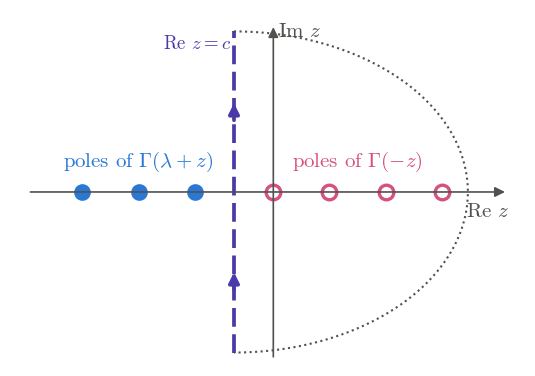

In [18]:
z = var('z')
show(laurent(gamma(-eps)*exp(-eps*euler_gamma), eps, 1))
print("residue of Gamma(z) at z = -2:", residue(gamma(z), z, -2))
mb_plane([-1.4, -2.4, -3.4], [0, 1, 2, 3], -0.7, r'$\Gamma(\lambda+z)$', r'$\Gamma(-z)$', close='right')

## 8. One-loop integrals the Package-X way

Passarino–Veltman coefficients (`PVB`, `PVC`, `PVD` with Package-X's index convention), their Taylor series about
zero momentum, their discontinuities across the cut, and C0 as an explicit formula:

In [19]:
s, m = var('s m')
show(PVB(1, 0, s, m, m))                                   # B00
show(PVB(0, 0, s, m, m, series=(s, 0, 2)))                 # B0 to order s^2
show(PVB(0, 0, s, m, m, disc=s))                           # the discontinuity across the cut

1/6*m^2*(1/eps + log(mu^2/m^2) + 1) + 1/3*m^2 + 1/12*(4*m^2 - s)*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2) - 1/18*s

-(eps*log(m^2) - 2*eps*log(mu) - 1)/eps + 1/6*s/m^2 + 1/60*s^2/m^4

2*I*pi*sqrt(-4*m^2*s + s^2)*heaviside(-4*m^2 + s)/s

In [20]:
print("C0(1, 10, 3; 1, 1, 1) =", C0(1, 10, 3, 1, 1, 1).n(digits=25))
cf = c0_expand(1, 10, 3, 1, 1, 1)                          # valid where the Kallen function of (1, 10, 3) is > 0
print("the explicit formula: ", cf.n({}))

C0(1, 10, 3; 1, 1, 1) = -0.006633062175974184280565385 - 0.9561385314366288639366086*I
the explicit formula:  -0.00663306217597418 - 0.956138531436629*I


Fermion lines with spinors, as Package-X's `FermionLine`: the Dirac equation at both ends and the Gordon identity
are used, and `projector` picks a form factor out of a vertex.

In [21]:
line_expand(("u", "p2", "m"), ["p1 + m", "mu"], ("u", "p1", "m"), sp={"p1^2": "m^2", "p2^2": "m^2"})

{((), '1'): p1__mu - p2__mu,
 ((('i', 'mu'),), '1'): 2*m,
 (('sigma', ('i', 'mu'), ('p', 'p2')), '1'): -I,
 (('sigma', ('i', 'mu'), ('p', 'p1')), '1'): I}

The answer is a dictionary. Each key is a Dirac structure with its chirality: `()` is the unit matrix,
`(('i', 'mu'),)` is γ^μ and `('sigma', a, b)` is σ^{ab}; `'1'` means no γ5. Each value is the coefficient, and
`p1__mu` means p1^μ. So ū(p2)(p̸1 + m)γ^μ u(p1) = ū(p2)[2m γ^μ + (p1 − p2)^μ + iσ^{μν}(p1 − p2)_ν]u(p1).

## 9. FORM directly

`form.compute` runs traces and index contractions in FORM without writing FORM code; `show_code=True` prints
the program it wrote.

In [22]:
from feynsage import form
form.compute("eps(mu,nu,rho,sigma)*eps(mu,nu,rho,sigma)", show_code=True)

Indices mu,nu,rho,sigma;
Local E = e_(mu,nu,rho,sigma)*e_(mu,nu,rho,sigma);
contract;
Format nospaces;
Print +s;
.end



24

## 10. Plots

`quick_plot` plots expressions with B0, C0, D0 and poles directly (real and imaginary parts); `curves` plots
several functions on one axis.

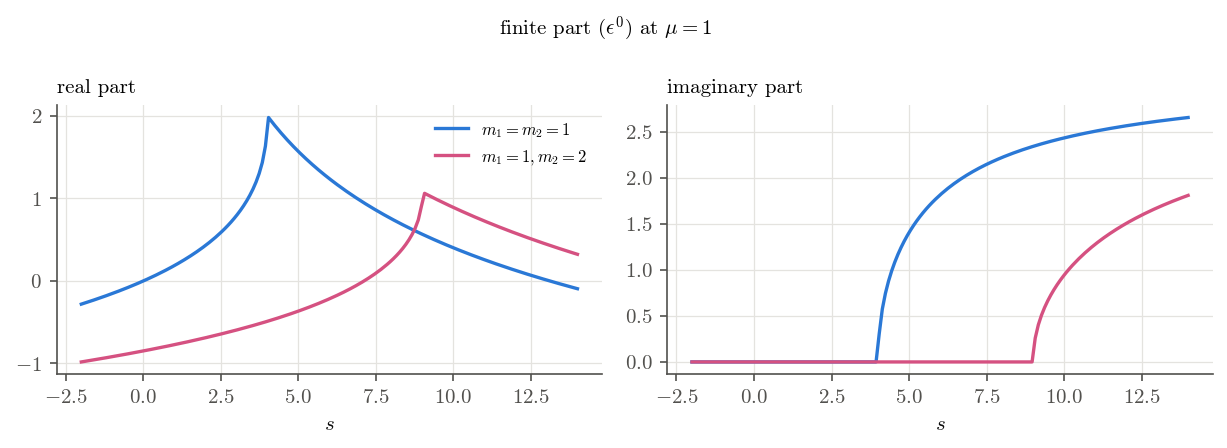

In [23]:
quick_plot([B0(s, 1, 1), B0(s, 1, 2)], (s, -2, 14), labels=["$m_1 = m_2 = 1$", "$m_1 = 1, m_2 = 2$"])

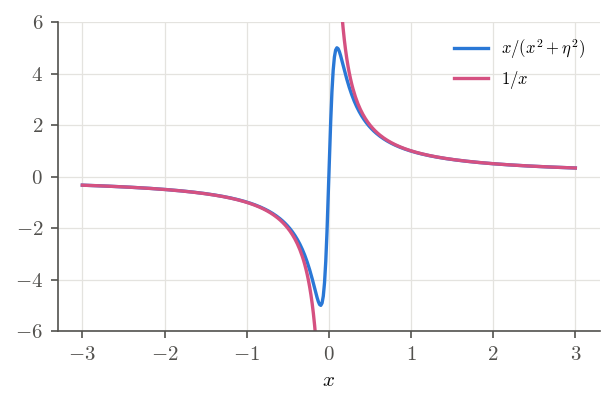

In [24]:
x = var('x')
curves([x/(x^2 + 0.1^2), 1/x], (-3, 3), labels=[r'$x/(x^2+\eta^2)$', '$1/x$'], ylim=(-6, 6))

## 11. Every core

Most heavy steps run on all cores by themselves. `set_nproc(n)` fixes the number of worker processes and
`pmap` runs any function on a list in parallel. `scan` evaluates an expression at many points:

In [25]:
print("cores used by feynsage:", cores())
vals = scan(finite_part(B0(s, 1, 1), 1), s, [1, 2, 3, 5, 10])
vals

cores used by feynsage: 4


[(0.18620063576577994+0j),
 (0.4292036732050999+0j),
 (0.79080042384385+0j),
 (1.569591059035996+1.4049629462081452j),
 (0.40166851924408964+2.4334672055841673j)]

In [26]:
pmap(lambda n: factorial(n).ndigits(), [100, 1000, 5000, 20000])

[158, 2568, 16326, 77338]

## 12. Diagrams from a model, like FeynArts

`topologies` and `insert_fields` make every diagram of a process from a model; the numbers of topologies and
diagrams are the same as FeynArts gives.

loops 0, 2 -> 2:  4 topologies
loops 1, 1 -> 1:  3 topologies
loops 1, 2 -> 2:  99 topologies
28 one-loop diagrams for H -> gamma gamma (W, Goldstone, ghost and top loops)


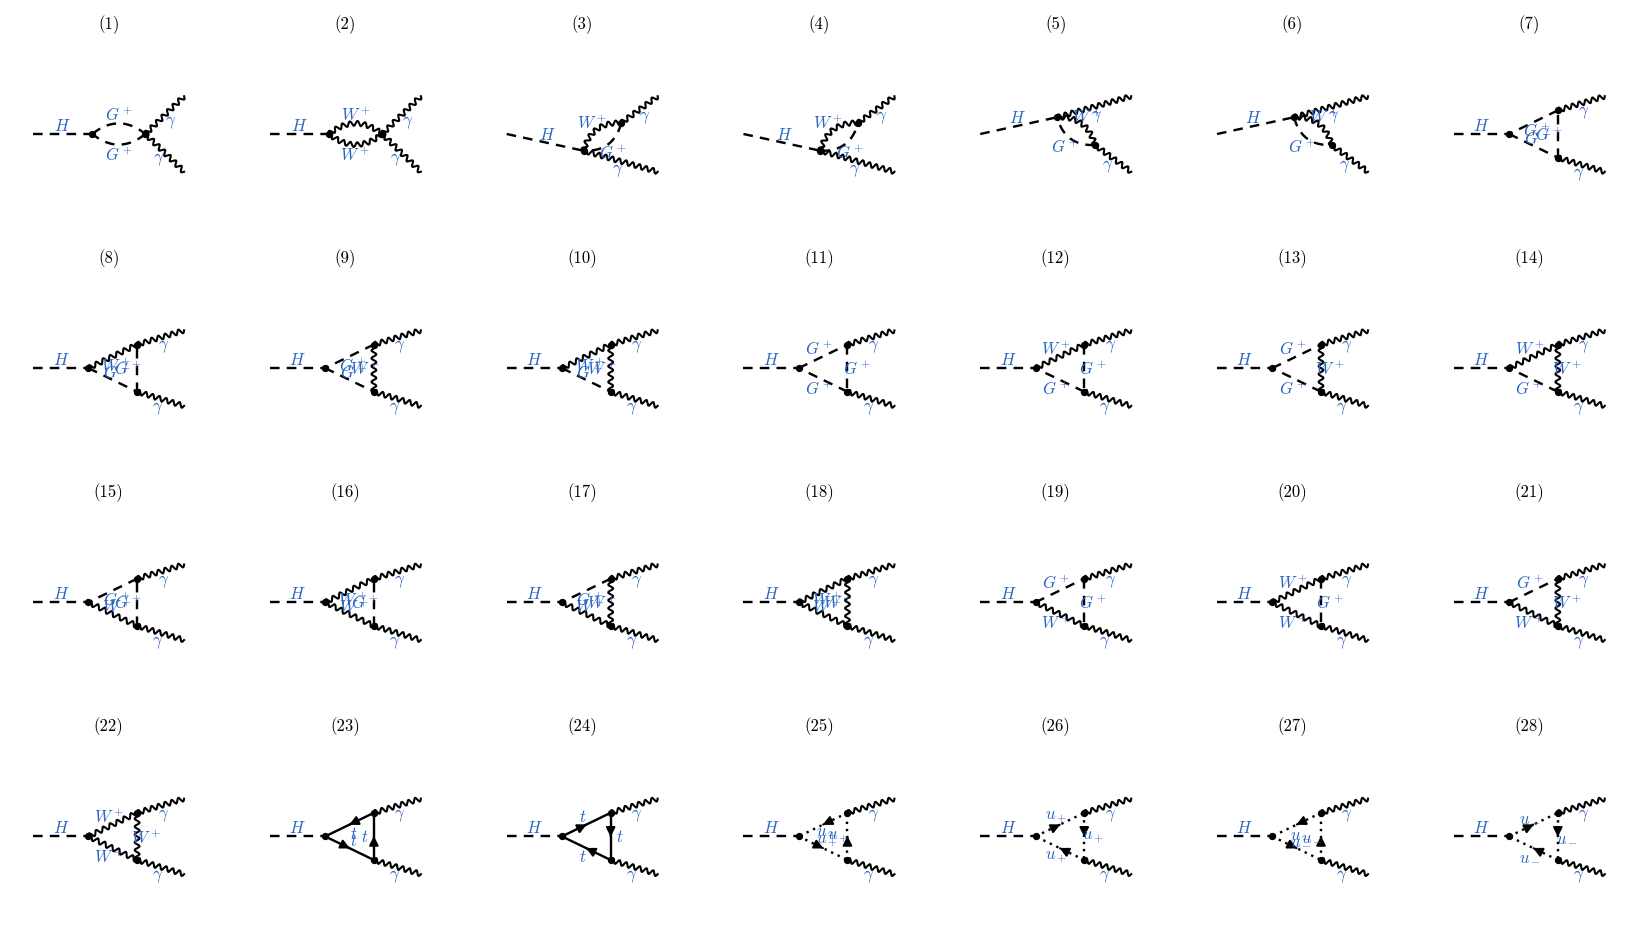

In [27]:
sm = SM()
for L, nin, nout in [(0, 2, 2), (1, 1, 1), (1, 2, 2)]:
    print("loops %d, %d -> %d:  %d topologies" % (L, nin, nout, len(topologies(L, nin, nout))))
d = insert_fields(topologies(1, 1, 2, exclude=("tadpoles", "wf")), ["H"], ["A", "A"], sm,
                  exclude_fields=['e', 'mu', 'ta', 'ne', 'nm', 'nt', 'u', 'c', 'd', 's', 'b'])
print(len(d), "one-loop diagrams for H -> gamma gamma (W, Goldstone, ghost and top loops)")
d.draw(ncols=7, size=1.6)

## 13. Help everywhere

`info(f)` prints what a function does and what its output means; many functions also take `explain=True`,
which prints that before working. `eq` shows a named equation.

In [28]:
info(ibp_reduce)

ibp_reduce
----------
Reduce integrals of a family to master integrals.

    ibp_reduce(kite, ["F(1,1,1,1,1)", (2,2,1,2,2)])

The seed range is chosen from the targets (enough dots and numerator powers), the
symmetries are found automatically (symmetries(fam)), and the method is
"ff" (finite fields, fast; at most one symbolic invariant besides d), "exact"
(Laporta with exact rational functions on every seeded equation) or "trimmed" (exact
Laporta on only the equations the targets need, found by one modular probe: exact
arithmetic, much faster than "exact").  "auto" picks ff when it can.
The finite-field samples run on every core when the system is big enough (nproc=None);
nproc=1 keeps it serial.


In [29]:
loop("l.p", ["l", "m"], ["l + p", "m"], kin={"p^2": "s"}, explain=True)

loop(): a one-loop integral reduced to scalar functions.
  Normalisation (Package-X / LoopTools): mu^(2 eps) e^(eps gamma_E) Int d^d l/(i pi^(d/2)),
  d = 4 - 2 eps, propagators 1/(q^2 - m^2 + i0) [Minkowski] or, with euclidean=True,
  Int d^d l/pi^(d/2) with 1/(q^2 + m^2) [Euclidean; the functions are then the Minkowski
  ones at p_M^2 = -p_E^2 times (-1)^N].
  Output: one line per tensor structure (g^{mu nu}, p^mu, ... or 1 for a scalar numerator),
  each with its coefficient expanded to eps^0.  The pieces are
    1/eps^2, 1/eps  poles: UV, and IR (soft/collinear) from divergent C0, D0 written out,
    A0, B0      written out: logs, LogM(z) = log(z - i0), DiscB(s, m1, m2) (see B0?),
    C0(...), D0(...)  IR-finite ones stay symbols; .n() gives > 30 digits, explicit() the dilogarithms,
    mu          the renormalisation scale.
  .masters() gives the exact coefficients in d before expanding; .coefficients() a dict.


1 :  -1/2*s*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2)

In [30]:
eq(r"\mathcal{U}_{\rm kite}", kite.U())

<IPython.core.display.Math object>